# Project Part 2: Data Understanding and Preparation

- **Team number:** `#`
- **Team members:** `Cole Beach`, `Eric Lindquist`, `Tuan Lo`
- **Dataset name:** `Music Genre Classification Dataset (train.csv / test.csv)`
- **Target variable:** `Class`

## 1. Problem and Data Snapshot

- **Dataset:** We use the music classification dataset from `data/raw/train.csv` for training and `data/raw/test.csv` for prediction.
- **Machine learning problem:** This is a supervised multiclass classification problem because each song has a labeled category.
- **Target variable:** The output to predict is `Class`.
- **Main input features expected to be used:**
  - Metadata features: `Artist Name`, `Track Name`, `Popularity`
  - Audio features: `danceability`, `energy`, `key`, `loudness`, `mode`, `speechiness`, `acousticness`, `instrumentalness`, `liveness`, `valence`, `tempo`, `duration_in min/ms`, `time_signature`

This project aims to learn patterns from track metadata and acoustic descriptors that are useful for predicting the correct music class.

## 2. Exploratory Data Analysis

This EDA uses a selective set of variables chosen for modeling relevance, distribution behavior, missingness, and relationship strength.

Dataset snapshot first: we verify overall size (`df.shape`) and schema (`df.info()` style view) so preprocessing decisions are grounded in sample size, numeric coverage, and missingness concentration. The data has enough observations for multiclass modeling, while missingness is concentrated in only a few features rather than spread uniformly.

**Focused variables:** `Popularity`, `energy`, `loudness`, `acousticness`, `instrumentalness`, `duration_in min/ms`, `speechiness`, `tempo` (target: `Class`).

This focused subset is intentional: it captures continuous audio descriptors with high modeling relevance and avoids diluting EDA with low-signal or encoding-heavy fields at this stage.

In [10]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", context="notebook")

train_path = "../data/raw/train.csv"
df = pd.read_csv(train_path)

focused_features = [
    "Popularity",
    "energy",
    "loudness",
    "acousticness",
    "instrumentalness",
    "duration_in min/ms",
    "speechiness",
    "tempo",
]
target_col = "Class"

eda_df = df[focused_features + [target_col]].copy()

# Basic EDA snapshot for context before focused analysis.
print("Dataset shape (rows, cols):", df.shape)

# Audit: check availability and missingness for selected features.
schema_snapshot = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing_pct": (df.isna().mean() * 100).round(3),
})

print("\nTop columns by missingness:")

audit = pd.DataFrame({
    "dtype": eda_df[focused_features].dtypes.astype(str),
    "missing_pct": (eda_df[focused_features].isna().mean() * 100).round(3),
    "n_unique": eda_df[focused_features].nunique(dropna=True),
}).sort_values("missing_pct", ascending=False)

audit

Dataset shape (rows, cols): (17996, 17)

Top columns by missingness:


,dtype,missing_pct,n_unique
instrumentalness,float64,24.322,4253
Popularity,float64,2.378,100
loudness,float64,0.000,9002
energy,float64,0.000,1208
acousticness,float64,0.000,3930
duration_in min/ms,float64,0.000,14121
speechiness,float64,0.000,1194
tempo,float64,0.000,13562


In [11]:
summary = eda_df[focused_features].describe(percentiles=[0.25, 0.5, 0.75]).T
summary = summary.rename(columns={"50%": "median", "25%": "q1", "75%": "q3"})
summary["iqr"] = summary["q3"] - summary["q1"]
summary["missing_pct"] = eda_df[focused_features].isna().mean() * 100
summary["skew"] = eda_df[focused_features].skew(numeric_only=True)

summary_table = summary[[
    "count",
    "missing_pct",
    "mean",
    "std",
    "min",
    "median",
    "max",
    "iqr",
    "skew",
]].round(3)

summary_table

,count,missing_pct,mean,std,min,median,max,iqr,skew
Popularity,17568.0,2.378,44.512,17.427,1.000,44.000,100.000,23.000,0.076
energy,17996.0,0.000,0.663,0.235,0.000,0.700,1.000,0.351,-0.661
loudness,17996.0,0.000,-7.911,4.049,-39.952,-7.016,1.355,4.349,-1.761
acousticness,17996.0,0.000,0.247,0.311,0.000,0.081,0.996,0.430,1.105
instrumentalness,13619.0,24.322,0.178,0.304,0.000,0.004,0.996,0.200,1.531
duration_in min/ms,17996.0,0.000,200744.459,111989.127,0.502,209160.000,1477187.000,86153.000,0.847
speechiness,17996.0,0.000,0.080,0.084,0.022,0.047,0.955,0.048,3.088
tempo,17996.0,0.000,122.623,29.572,30.557,120.066,217.416,42.348,0.380


### Focused Feature Distributions (Histogram)

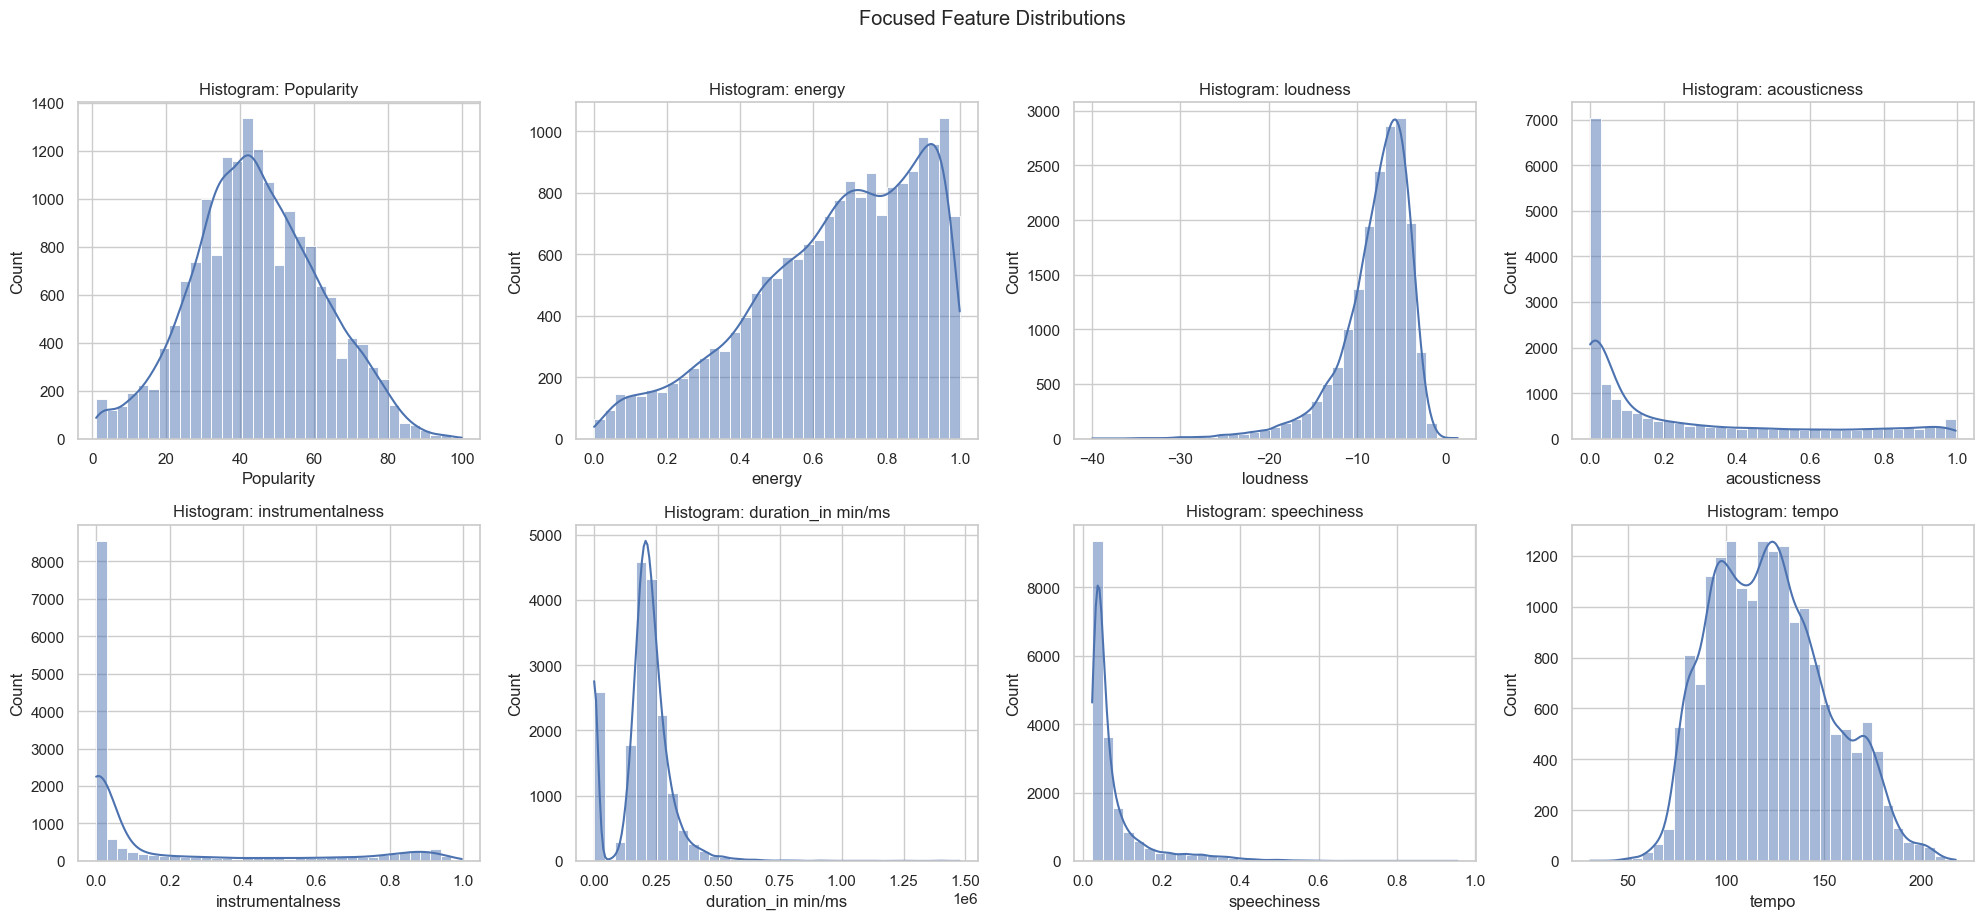

In [12]:
# Question: What are the distribution shapes and skew patterns of focused features?
plot_df = eda_df[focused_features].copy()

fig, axes = plt.subplots(2, 4, figsize=(20, 9))
for i, col in enumerate(focused_features):
    ax = axes[i // 4, i % 4]
    sns.histplot(plot_df[col], bins=35, kde=True, ax=ax, color="#4C72B0")
    ax.set_title(f"Histogram: {col}")
    ax.set_xlabel(col)

plt.suptitle("Focused Feature Distributions", y=1.02)
plt.tight_layout()
plt.show()

- Histogram shape confirms that `speechiness`, `acousticness`, and `duration_in min/ms` are right-skewed (positive skew means a long right tail: most tracks sit at lower values with a smaller set of extreme high values).
- This skewness matters because tails can pull linear decision boundaries and distance metrics; robust scaling is preferred over standard scaling for these features, and `log1p` is a reasonable sensitivity check for heavy-tail variables.
- `instrumentalness` has both high missingness and a mass near low values, suggesting many vocal-dominant tracks with a minority of highly instrumental songs. Keep it, impute it, and add a missing-indicator so models can capture both value signal and missingness pattern.
- `duration_in min/ms` has wide spread and clear outliers; tree ensembles usually tolerate this directly, while linear or margin-based models should use clipping/transforms to reduce instability.

### Outlier and Tail Diagnostics (Boxplots)

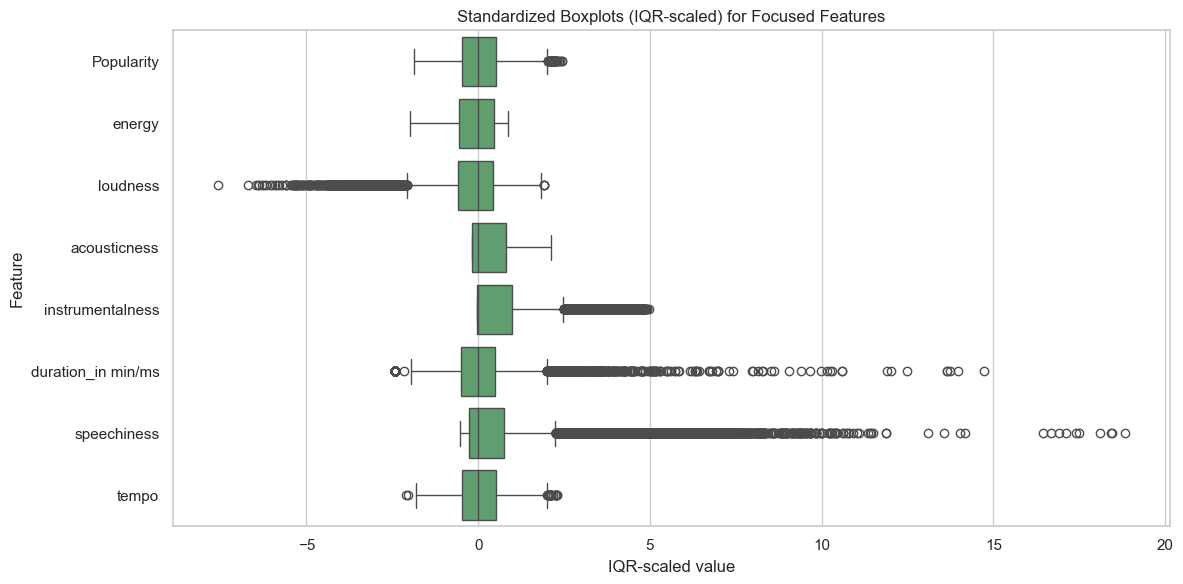

In [ ]:
# Question: Which focused features have heavy tails or potential outliers?
long_df = eda_df[focused_features].melt(var_name="feature", value_name="value")

# Standardize within feature so spread is comparable in one compact chart.
long_df["z_value"] = long_df.groupby("feature")["value"].transform(
    lambda x: (x - x.median()) / (x.quantile(0.75) - x.quantile(0.25) + 1e-9)
)

plt.figure(figsize=(12, 6))
sns.boxplot(data=long_df, x="z_value", y="feature", orient="h", whis=1.5, color="#55A868")
plt.title("Standardized Boxplots (IQR-scaled) for Focused Features")
plt.xlabel("IQR-scaled value")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

- The standardized boxplots reinforce a heavy-tail profile in several focused variables: `duration_in min/ms`, `speechiness`, and `acousticness` show broader IQR-scaled spread with more extreme points than relatively tighter features.
- `duration_in min/ms` stands out as the most outlier-prone feature, which supports using robust preprocessing (robust scaling and optional clipping/transform sensitivity checks) before linear or distance-based models.
- Outlier density differs by feature rather than appearing uniformly, so a feature-specific treatment strategy is preferable to global row-level outlier removal.
- Because many extreme values in music features can be genuine genre/style signal (not pure noise), keep these observations in baseline models and validate any clipping/removal via cross-validated ablations.

### Correlation Structure of Focused Features

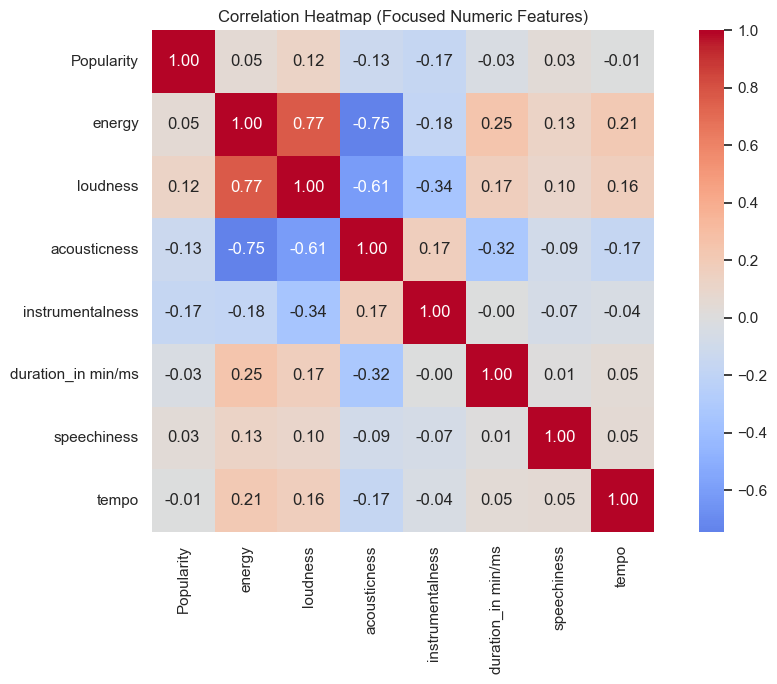

In [14]:
# Question: Which focused features move together strongly?
corr = eda_df[focused_features].corr()

plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Correlation Heatmap (Focused Numeric Features)")
plt.tight_layout()
plt.show()

- The heatmap indicates a clear correlation cluster among `energy`, `loudness`, and `acousticness`, consistent with overlapping musical intensity/timbre structure in the feature space.
- This level of collinearity can destabilize coefficient estimates in unregularized linear models, so regularization (or feature-drop ablations) is important for interpretability and generalization.
- Correlation here should be treated as a redundancy signal, not automatic deletion logic: keep the cluster in baseline runs and verify value-add by model family (linear vs tree-based).
- Because `Class` is categorical, this matrix is useful for feature-feature dependency diagnostics only; class relevance should continue to be judged with class-aware methods (ANOVA/MI and class-conditional plots).

### Strongest Pairwise Relationships (Scatterplots)

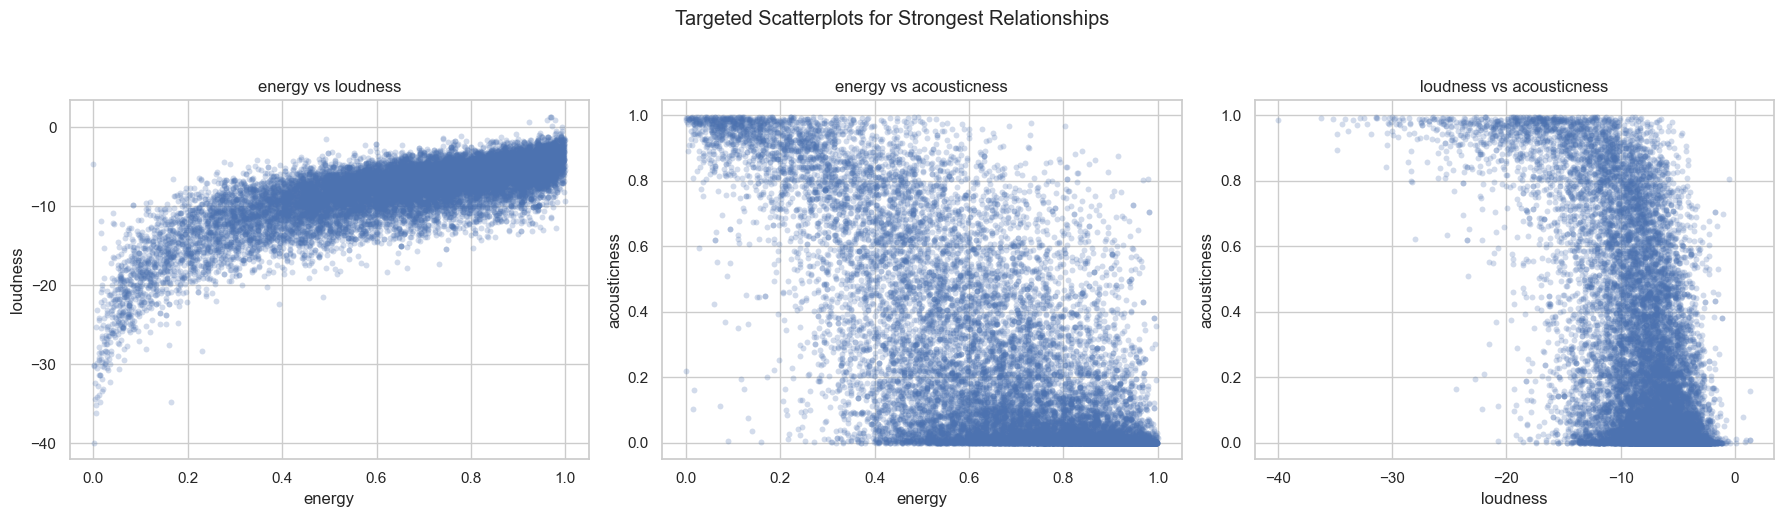

In [15]:
# Question: How do the strongest correlated feature pairs behave?
scatter_pairs = [
    ("energy", "loudness"),
    ("energy", "acousticness"),
    ("loudness", "acousticness"),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (x_col, y_col) in zip(axes, scatter_pairs):
    sns.scatterplot(
        data=eda_df,
        x=x_col,
        y=y_col,
        alpha=0.25,
        s=18,
        linewidth=0,
        ax=ax,
    )
    ax.set_title(f"{x_col} vs {y_col}")

plt.suptitle("Targeted Scatterplots for Strongest Relationships", y=1.03)
plt.tight_layout()
plt.show()

Correlation conclusions for modeling:

- `energy`, `loudness`, and `acousticness` form a correlated cluster (strong pairwise relationships), so they are partially redundant for linear models and can inflate coefficient variance without regularization.
- Redundancy does **not** mean immediate removal. We keep the cluster initially because each feature can still add complementary nonlinear signal, especially for tree-based models.
- Practical strategy: keep all three for baseline models, then use regularization and ablation tests to decide whether dropping one improves generalization and interpretability.

### Class Separation in Top Signal Features (MI + ANOVA)

,anova_f,anova_pvalue,mutual_info
duration_in min/ms,1484.9658,0.0,0.3509
acousticness,947.4509,0.0,0.2774
energy,833.6812,0.0,0.2139
instrumentalness,551.6458,0.0,0.1718
speechiness,807.7890,0.0,0.1414
loudness,785.5009,0.0,0.1303
Popularity,203.9523,0.0,0.0978
tempo,42.5693,0.0,0.0706


Top 3 class-signal features (categorical-safe ranking): ['duration_in min/ms', 'acousticness', 'energy']


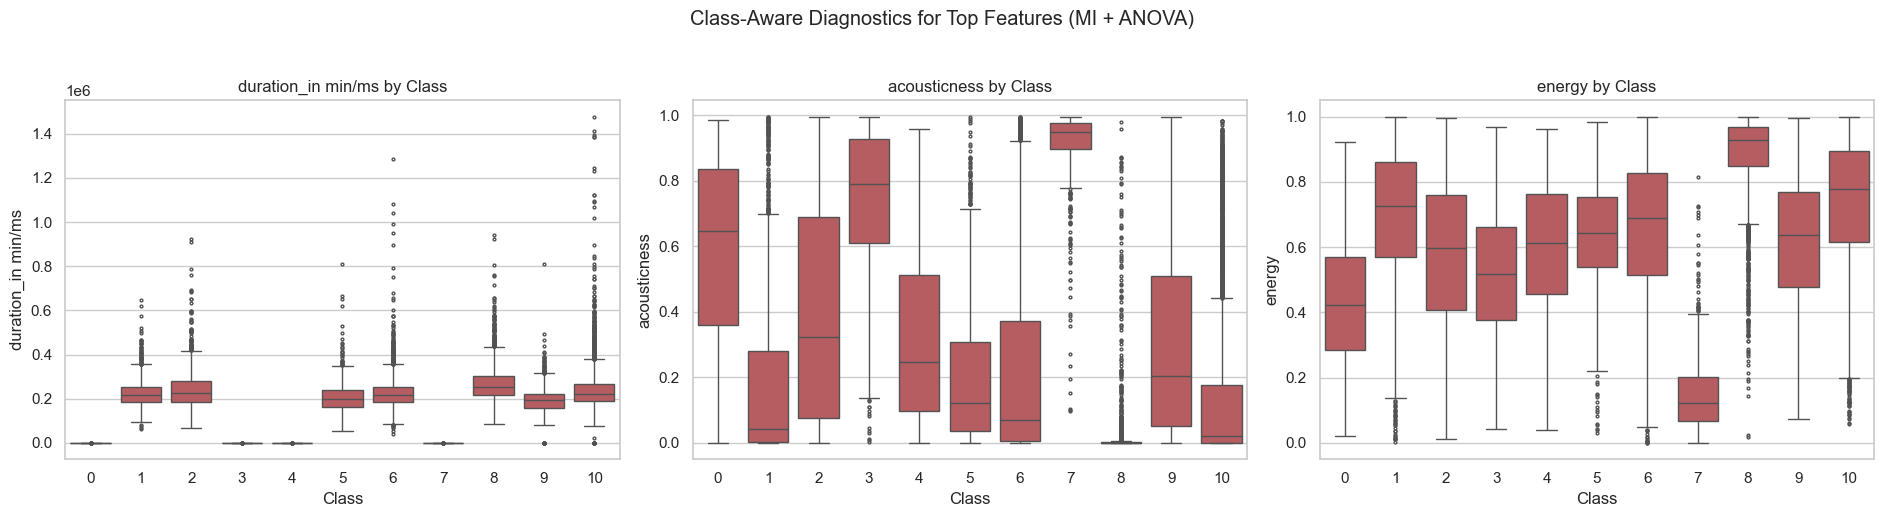

In [16]:
# Question: Which top signal features differ most across classes?
# `Class` is categorical, so Pearson correlation to class codes is not appropriate.
from sklearn.feature_selection import f_classif, mutual_info_classif

X = eda_df[focused_features].copy()
y = eda_df[target_col].copy()

# Handle missingness for score computation.
X_imputed = X.fillna(X.median(numeric_only=True))

f_vals, p_vals = f_classif(X_imputed, y)
mi_vals = mutual_info_classif(X_imputed, y, random_state=42)

signal_rank = pd.DataFrame({
    "anova_f": f_vals,
    "anova_pvalue": p_vals,
    "mutual_info": mi_vals,
}, index=focused_features).sort_values(["mutual_info", "anova_f"], ascending=False)

display(signal_rank.round(4))

top3_by_class_signal = signal_rank.head(3).index.tolist()
print("Top 3 class-signal features (categorical-safe ranking):", top3_by_class_signal)

fig, axes = plt.subplots(1, 3, figsize=(19, 5), sharex=False)
for ax, feature in zip(axes, top3_by_class_signal):
    sns.boxplot(data=eda_df, x=target_col, y=feature, ax=ax, color="#C44E52", fliersize=2)
    ax.set_title(f"{feature} by Class")
    ax.set_xlabel("Class")

plt.suptitle("Class-Aware Diagnostics for Top Features (MI + ANOVA)", y=1.03)
plt.tight_layout()
plt.show()

- The class-conditional boxplots confirm that top-ranked features from MI + ANOVA (`duration_in min/ms`, `acousticness`, `energy`) show meaningful distribution shifts across classes rather than uniform overlap.
- Separation is present but not cleanly linear: several classes still overlap in central ranges, indicating that interaction effects and nonlinear boundaries are likely important for final performance.
- `duration_in min/ms` contributes strong class signal, but its broad spread/outlier behavior suggests this feature should be paired with robust preprocessing checks (scaling/transform sensitivity in linear-distance models).
- Because rank metrics and boxplots agree directionally, these features are justified for baseline inclusion; final keep/drop decisions should still be made through cross-validated ablation by model family.

In [17]:
# Question: Is class imbalance large enough to affect model training and evaluation?
class_counts = df[target_col].value_counts().sort_index()
class_pct = (class_counts / class_counts.sum() * 100).round(2)
imbalance_ratio = class_counts.max() / class_counts.min()

class_balance = pd.DataFrame({
    "count": class_counts,
    "pct": class_pct,
})

print(f"Imbalance ratio (largest/smallest class): {imbalance_ratio:.2f}x")
class_balance

Imbalance ratio (largest/smallest class): 12.79x


,count,pct
Class,,
0,625,3.47
1,1373,7.63
2,1272,7.07
3,402,2.23
4,387,2.15
5,1447,8.04
6,2587,14.38
7,576,3.20
8,1854,10.30


### Modeling implications

1. **Imputation first:** keep `instrumentalness`, apply median imputation, and add a missing-indicator so missingness can be learned as signal.
2. **Encoding choices:** treat `key` as categorical (not continuous) if included; remove it if cross-validation shows negligible gain.
3. **Scale/transform policy:** use robust scaling for skewed heavy-tail variables (`speechiness`, `acousticness`, `duration_in min/ms`), then test `log1p` as an ablation for linear-distance models.
4. **Correlation management:** keep `energy`/`loudness`/`acousticness` initially; control redundancy with regularization and feature-drop ablations, especially for linear models.
5. **Class-aware training/evaluation:** because classes are imbalanced, prioritize macro-F1 and balanced accuracy, and start with class weights before oversampling.
6. **Leakage-risk check:** compare metadata-augmented models against audio-only baselines to ensure performance is not driven by brittle dataset shortcuts.
7. **Validation discipline:** lock all preprocessing in a pipeline and confirm each EDA-motivated choice through cross-validated ablation, not EDA alone.

## 3. Data Quality and Cleaning

This section documents the data-quality checks and cleaning actions used before modeling.

- **Missing values**
  - **Issue:** Missingness is concentrated in a few columns, especially `instrumentalness`, with smaller gaps in `Popularity` and `key`.
  - **Change:** Impute missing values in `instrumentalness`, `Popularity`, and `key` using each column median.
  - **Why reasonable:** Median imputation is robust to skew and extreme values and preserves sample size.
  - **Model impact:** Keeps training rows that would otherwise be dropped; however, imputation can compress variance near the center, so this should be validated in cross-validation.

- **Duplicate records**
  - **Issue:** Exact duplicate rows are present in the raw training data.
  - **Change:** Remove exact duplicates with `drop_duplicates(keep="first")` and report before/after counts.
  - **Why reasonable:** Duplicates can overweight repeated examples and bias fit/metrics.
  - **Model impact:** Improves estimate reliability by reducing artificial repetition.

- **Invalid ranges and invalid zeros**
  - **Issue checked:** Bounded audio features (for example `energy`, `danceability`, `acousticness`, `instrumentalness`, `liveness`, `valence`, `speechiness`) should lie in `[0,1]`; variables like `tempo` and `duration_in min/ms` should be positive.
  - **Change:** Audit these constraints and report violations (if none, explicitly state none found).
  - **Why reasonable:** Constraint checks catch clearly invalid entries without arbitrary edits.
  - **Model impact:** Prevents corrupted values from distorting scaling and decision boundaries.

- **Outliers / extreme values**
  - **Issue:** Features such as `duration_in min/ms` and `tempo` can have heavy tails.
  - **Change:** Quantify outliers with an IQR-based diagnostic report; keep values unchanged in this notebook stage.
  - **Why reasonable:** For this dataset size, immediate trimming risks deleting valid rare songs; diagnostics-first is safer before model-based validation.
  - **Model impact:** Tree models are typically robust to extremes, while linear/distance models may need robust scaling or transforms in the modeling pipeline.

- **Inconsistent labels and clearly invalid entries**
  - **Issue checked:** Target label consistency and obvious invalid entries are reviewed via audits.
  - **Change:** Report findings explicitly; do not alter values unless a concrete rule is justified.
  - **Why reasonable:** Ensures transparency and reproducibility.
  - **Model impact:** Reduces hidden leakage/noise risks in downstream evaluation.

- **Feature inclusion decisions (preprocessing, not pure cleaning)**
  - `Artist Name` and `Track Name` are removed from this baseline because high-cardinality identifiers can cause leakage-like memorization and unstable generalization.
  - `danceability` and `mode` are also removed in this baseline to limit early feature-space complexity; this is treated as a modeling choice to validate by ablation, not as a claim that these variables are inherently invalid.

Overall, the policy is conservative: correct clear quality issues, preserve plausible observations, and defer aggressive transformations/removals until cross-validated modeling confirms a benefit.


In [20]:
import pandas as pd

# Load raw training data for quality audit and cleaning.
data = pd.read_csv("../data/raw/train.csv")

print(f"Rows before cleaning: {len(data):,}")

# 1) Missingness audit before cleaning.
missing_before = data[["instrumentalness", "Popularity", "key"]].isna().sum()
print("\nMissing values before imputation:")
print(missing_before)

# 2) Duplicate audit and removal.
dup_before = data.duplicated().sum()
print(f"\nExact duplicates before removal: {dup_before:,}")
data = data.drop_duplicates(keep="first").copy()
dup_after = data.duplicated().sum()
print(f"Exact duplicates after removal: {dup_after:,}")
print(f"Rows after duplicate removal: {len(data):,}")

# 3) Median imputation for selected columns.
impute_cols = ["instrumentalness", "key", "Popularity"]
for col in impute_cols:
    data[col] = data[col].fillna(data[col].median())

missing_after = data[impute_cols].isna().sum()
print("\nMissing values after imputation:")
print(missing_after)

# 4) Invalid range checks for bounded features expected in [0, 1].
bounded_features = [
    "danceability", "energy", "speechiness", "acousticness",
    "instrumentalness", "liveness", "valence"
]
range_violations = {
    col: int(((data[col] < 0) | (data[col] > 1)).sum())
    for col in bounded_features if col in data.columns
}
print("\nRange violations for [0,1] features:")
print(pd.Series(range_violations).sort_values(ascending=False))

# 5) Invalid-zero checks where zero is generally implausible as a measured value.
invalid_zero_fields = ["tempo", "duration_in min/ms"]
invalid_zero_counts = {
    col: int((data[col] <= 0).sum())
    for col in invalid_zero_fields if col in data.columns
}
print("\nInvalid-zero checks (<= 0):")
print(pd.Series(invalid_zero_counts).sort_values(ascending=False))

# 6) Outlier diagnostics using IQR counts (diagnostic only, no trimming here).
outlier_features = ["tempo", "duration_in min/ms", "loudness", "Popularity", "instrumentalness"]
iqr_report = []
for col in outlier_features:
    if col not in data.columns:
        continue
    q1 = data[col].quantile(0.25)
    q3 = data[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outlier_count = int(((data[col] < lower) | (data[col] > upper)).sum())
    iqr_report.append({
        "feature": col,
        "q1": q1,
        "q3": q3,
        "iqr": iqr,
        "lower_bound": lower,
        "upper_bound": upper,
        "outlier_count": outlier_count,
        "outlier_pct": round(outlier_count / len(data) * 100, 3),
    })

print("\nIQR outlier diagnostic report (no values removed):")
print(pd.DataFrame(iqr_report).sort_values("outlier_pct", ascending=False))

# 7) Label and invalid-entry sanity checks.
print("\nTarget label checks:")
print(f"Missing Class labels: {int(data['Class'].isna().sum())}")
print(f"Unique Class labels: {int(data['Class'].nunique())}")

# 8) Baseline feature-removal choice for modeling (not a pure cleaning claim).
baseline_drop_cols = ["Artist Name", "Track Name", "mode", "danceability"]
data_model = data.drop(columns=[c for c in baseline_drop_cols if c in data.columns])
print("\nColumns dropped for baseline modeling:", baseline_drop_cols)
print(f"Rows retained for modeling: {len(data_model):,}")
print(f"Columns retained for modeling: {data_model.shape[1]}")

Rows before cleaning: 17,996

Missing values before imputation:
instrumentalness    4377
Popularity           428
key                 2014
dtype: int64

Exact duplicates before removal: 0
Exact duplicates after removal: 0
Rows after duplicate removal: 17,996

Missing values after imputation:
instrumentalness    0
key                 0
Popularity          0
dtype: int64

Range violations for [0,1] features:
danceability        0
energy              0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
dtype: int64

Invalid-zero checks (<= 0):
tempo                 0
duration_in min/ms    0
dtype: int64

IQR outlier diagnostic report (no values removed):
              feature             q1            q3           iqr  \
4    instrumentalness       0.000294       0.05660      0.056306   
1  duration_in min/ms  166337.000000  252490.00000  86153.000000   
2            loudness      -9.538000      -5.18900      4.349000   
3        

## 4. Model Readiness Reflection

Most important patterns

* Music has a lot of variation, so genre may be quite hard to predict
* Acousticness, loudness and energy have strong pairwise relationships

Most important data quality issues

* Several 'nan' entries that need to be weeded out
* Tossing out variables that do not need to be there, which can be changed later if necessary. Duration and popularity can be removed if necessary but they may add to finding the correct genre later
* Duplicate removal


Useful Features
* Strong correlation between 3 of the variables
* Many entries reduces chance of outliers having a meaningful impact on the model
* Supervised, the training set includes which entry goes to which class, so we don't have to do it manual (thank god)

Preprocessing and modeling challenges

* Finding the correct variables to remove
* Weeding out any potential outliers, which will prove difficult since there are many entries
* Finding a good balance between model and data, as some of the variables can be redundant due to high correlation
